### Parkinson detection model using support vector machine model

**Primary Objective**

##### To develop and evaluate a machine learning–based decision support model using Support Vector Machines (SVM) to accurately distinguish between individuals with Parkinson’s disease and healthy controls based on biomedical voice features.

#### Specific objectives
- To preprocess and standardize clinical voice-related features for optimal model performance

- To train an SVM classifier capable of detecting Parkinson’s disease with high discriminative ability

- To evaluate model performance using clinically meaningful metrics beyond accuracy (ROC–AUC, precision, recall, cross-validation)

- To assess the robustness and generalizability of the model using cross-validated ROC–AUC

- To demonstrate the feasibility of machine learning as a screening and early detection support tool for Parkinson’s disease

#####  Health System Use Cases
**Early Screening & Risk Stratification**

- The model can serve as a non-invasive, low-cost screening tool using voice measurements to identify individuals at higher risk of Parkinson’s disease.

- This is particularly valuable in resource-limited settings where access to neurologists and advanced diagnostic tools is constrained.

**Uses**

- Earlier identification of suspected cases

- Faster referral to neurology specialists

- Reduction in late-stage diagnoses

**Clinical Decision Support for Neurologists**

- The SVM model can function as a clinical decision support system (CDSS), providing probabilistic risk scores (ROC–AUC ≈ 0.82; CV ROC–AUC ≈ 0.90).

- Supports, but does not replace, clinical judgment.

**Uses**

- Objective, data-driven insights to complement clinical assessment

- Improved diagnostic confidence, especially in borderline or early-stage cases

**Telemedicine and Remote Monitoring**

- Since the model relies on data from voice features, it is well-suited for remote assessments.

- Patients can submit voice recordings from home, enabling follow-up without frequent hospital visits.

**Uses**
- Reduced patient burden

- Improved continuity of care

- Scalable monitoring for chronic neurological conditions

**Population Health & Research Applications**

- Health systems and research institutions can deploy the model for:

- Epidemiological studies

- Large-scale screening programs

- Identifying cohorts for clinical trials

**Uses**

- Data-driven population insights

- More efficient recruitment for Parkinson’s research

In [42]:
# Importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [4]:
#Importing data
data= pd.read_csv("parkinsons.csv")

#### Examining data set

In [5]:
# Displaying the first 5 rows of all the columns
pd.set_option("display.max_columns", None)

data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [6]:
# number of records and fields in the dataframe
data.shape

(195, 24)

#### More information on the dataset

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [8]:
#Checking for missing values 
data.isna().sum().sum()

np.int64(0)

In [9]:
### Getiing some statistics measures  about the data
data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,0.015664,0.017878,0.024081,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,0.010153,0.012024,0.016947,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,0.004550,0.005700,0.007190,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,0.008245,0.009580,0.013080,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,0.012790,0.013470,0.018260,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,0.020265,0.022380,0.029400,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,0.056470,0.079400,0.137780,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [10]:
## Examining the target distribution
status_counts = data["status"].value_counts()
# 1---> Parkinson's positive
# 0---> Free from parkinson's
print(status_counts)
# Shows that minority cases were 25% 

status
1    147
0     48
Name: count, dtype: int64


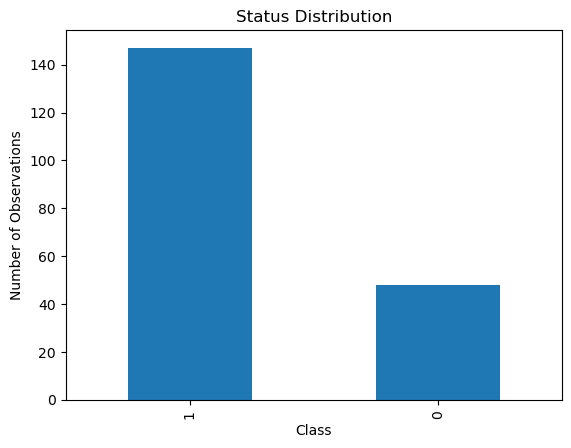

In [11]:
# Plotting status counts
status_counts.plot(kind='bar')
plt.title("Status Distribution")
plt.ylabel("Number of Observations")
plt.xlabel("Class")
plt.show()


In [12]:
# Examining for imbalance in datasets
# Percentage of each class
class_percentages = data['status'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'Count': status_counts,
    'Percentage (%)': class_percentages.round(2)
})

imbalance_df
# This shows that the minority class (Parkinson's disease patients are 25% of the dataset)

,Count,Percentage (%)
status,,
1,147,75.38
0,48,24.62


In [13]:
#  Explanation: This is mild imbalance
# Using accuracy as the only metircs for model performance becomes misleading and precison and recall should be deployed in addition.

In [43]:
# Grouping the data based on the target variable
data.groupby("status").mean(numeric_only=True)

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
status,,,,,,,,,,,,,,,,,,,,,,
0,181.937771,223.636750,145.207292,0.003866,0.000023,0.001925,0.002056,0.005776,0.017615,0.162958,0.009504,0.010509,0.013305,0.028511,0.011483,24.678750,0.442552,0.695716,-6.759264,0.160292,2.154491,0.123017
1,145.180762,188.441463,106.893558,0.006989,0.000051,0.003757,0.003900,0.011273,0.033658,0.321204,0.017676,0.020285,0.027600,0.053027,0.029211,20.974048,0.516816,0.725408,-5.333420,0.248133,2.456058,0.233828


### Data PreProcessing

#### Separating the features and target

In [44]:
## Remove name column and separate target variable
X = data.drop(columns=["name", "status"], axis=1)
y= data['status']

##### Splitting the data to training and test data

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =2)

#### Data standardization

In [46]:
# Bring all the columns into the same range
scaler = StandardScaler()

In [47]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [48]:
# After fitting convert all the values in the same range. After scaling all data is in range -1 to 1
X_train_scaled= scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test) #We do not fit the test data so the model do not have to see the data before


In [49]:
X_train_scaled

array([[ 0.63239631, -0.02731081, -0.87985049, ..., -0.97586547,
        -0.55160318,  0.07769494],
       [-1.05512719, -0.83337041, -0.9284778 , ...,  0.3981808 ,
        -0.61014073,  0.39291782],
       [ 0.02996187, -0.29531068, -1.12211107, ..., -0.43937044,
        -0.62849605, -0.50948408],
       ...,
       [-0.9096785 , -0.6637302 , -0.160638  , ...,  1.22001022,
        -0.47404629, -0.2159482 ],
       [-0.35977689,  0.19731822, -0.79063679, ..., -0.17896029,
        -0.47272835,  0.28181221],
       [ 1.01957066,  0.19922317, -0.61914972, ..., -0.716232  ,
         1.23632066, -0.05829386]], shape=(156, 22))

In [50]:
## NB you can standardize the data before splitting and vice versa

#### Model training

##### Support vector machine model

In [51]:
model = svm.SVC(kernel = 'linear',
               probability = True,
                random_state=42)              

In [52]:
# Training model with training data
model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Model Evaluation

##### Accuracy score

In [53]:
# Accuracy score on training data
X_train_prediction = model.predict(X_train_scaled)
training_data_accuracy = accuracy_score (y_train, X_train_prediction)

In [54]:
print('Accuracy score of training data : ',training_data_accuracy)

Accuracy score of training data :  0.8846153846153846


In [55]:
# Accuracy score on test data
X_test_prediction = model.predict(X_test_scaled)
test_data_accuracy = accuracy_score (y_test, X_test_prediction)

In [56]:
print('Accuracy score of test data : ',test_data_accuracy)

Accuracy score of test data :  0.8717948717948718


In [57]:
# This shows that the model performance is good for both the training and test data sets

#### Make predictions

In [58]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for positive class

In [59]:
print("Classification Report – SVM")
print(classification_report(y_test, y_pred))

Classification Report – SVM
              precision    recall  f1-score   support

           0       0.71      0.62      0.67         8
           1       0.91      0.94      0.92        31

    accuracy                           0.87        39
   macro avg       0.81      0.78      0.79        39
weighted avg       0.87      0.87      0.87        39



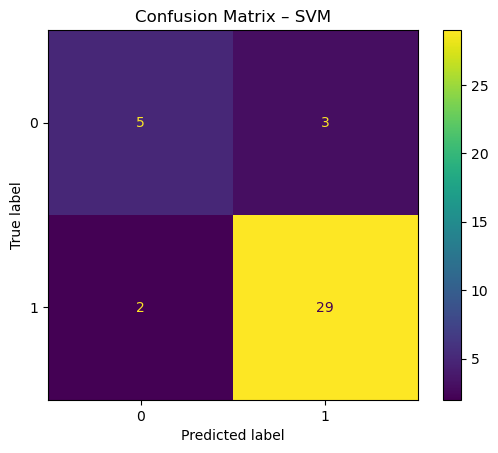

In [68]:
##Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("Confusion Matrix – SVM")
plt.savefig('Confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


#### ROC_AUC CALCULATION AND CURVE

ROC–AUC Score: 0.8185


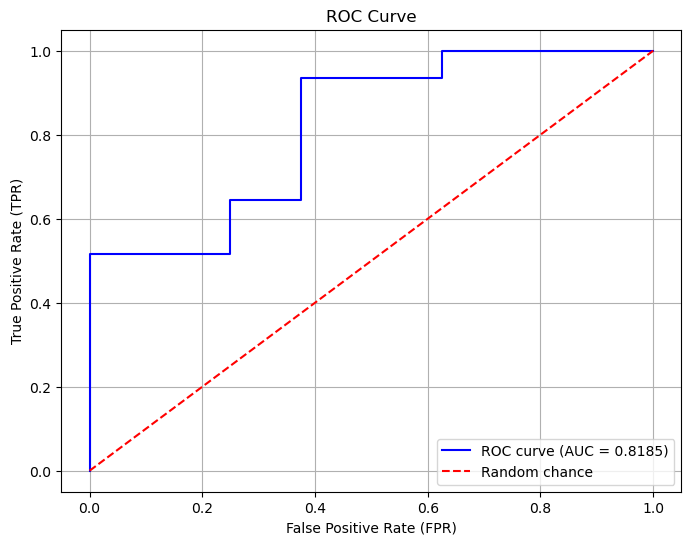

In [66]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC–AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random chance')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('ROC_CURVE.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Receiver operating characteristics curve which plots true positive rate vs false positive rate (FPR) at different thresholds. 
#AUC = Area under the courve summarizes the ROC curve as a single number between 0 and 1. It measures how well the model can distinguish positive and negative cases.
# In  the model here, the model shows good ability to separate positive and negative cases. 

In [40]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("CV ROC–AUC:", cv_auc.mean())


CV ROC–AUC: 0.8963768115942029


In [ ]:
# When compared to your earlier ROC–AUC (≈0.818), this suggests, on average, the model performs better across multiple folds than on that single test set.

#### Hyperparameter evaluation

In [69]:
from sklearn.model_selection import GridSearchCV

model = SVC(probability=True, random_state=42)

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "gamma": [0.001, 0.01, 0.1, "scale"],
    "kernel": ["linear"]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_svm = grid.best_estimator_


In [67]:
print(best_svm)

SVC(C=1, gamma=0.001, kernel='linear', probability=True, random_state=42)


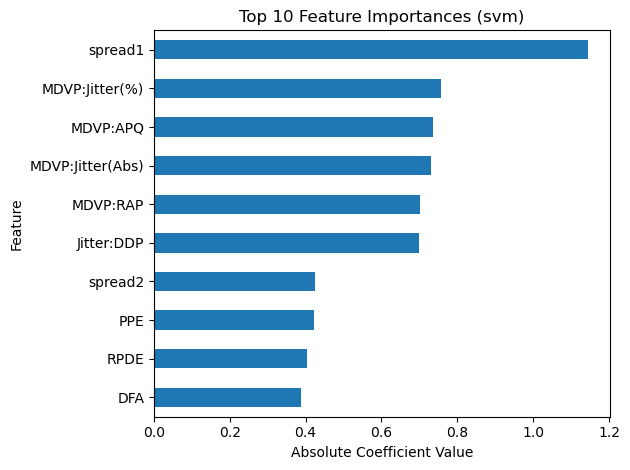

In [67]:
# Create importance series
feature_names = X_train.columns
importance = (
    pd.Series(model.coef_[0], index= feature_names)
    .abs()
    .sort_values(ascending=False)
)

# Select top 10 features
top_features = importance.head(10)

# Plot
plt.figure()
top_features.sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances (svm)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig('figure.png', dpi=300, bbox_inches='tight')
plt.show()


#### Building a predicting system

In [25]:
input_data = (95.73,	132.068,	91.754,	0.00551,	0.00006,	0.00293,	0.00332,	0.0088,	0.02093,	0.191,	0.01073,	0.01277,	0.01717,	0.03218,	0.0107,	21.812,		0.615551,	0.773587,	-5.498678,	0.327769,	2.322511,	0.231571)

#changing input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

#reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1) #tells the model you are evaluating one data point

#Standardizing the data

std_data = scaler.transform(input_data_reshaped)

prediction = model.predict(std_data)
print(prediction)

if (prediction[0] == 0):
    print("The Person does not have Parkinson's disease")
else:
    print("The Person has Parkinson's disease")

[1]
The Person has Parkinson's disease


## Key Model Performance Insights
- Test Accuracy: ~87%

- ROC–AUC: ~0.82 (good discrimination between diseased and non-diseased cases)

- Cross-Validated ROC–AUC: ~0.90 (strong generalizability and robustness)

- Balanced Precision & Recall: Indicates reliable detection without excessive false positives or false negatives

##### Recommendations

**Use as a Support Tool, Not a Standalone Diagnostic**

- he model should be applied as an adjunct to clinical evaluation, not as a definitive diagnostic tool.

- Final diagnosis must remain with trained clinicians using comprehensive neurological assessment.

**Integrate into Early-Stage Evaluation Pathways**

- Consider incorporating the model during:

  - Initial assessments of patients with subtle or early motor symptoms

  - Follow-up evaluations where symptoms are evolving

**Focus on Early Intervention**

- Patients flagged as high-risk can be:

  - Referred earlier for confirmatory testing

  - Enrolled in monitoring or early intervention programs

**Support Remote and Community-Based Care**

- Especially relevant for:

  - Rural or underserved populations

  - Patients with limited access to specialist care

**Continuous Model Improvement**

- Clinicians and data teams should collaborate to:

  - Periodically retrain the model with new patient data

  - Validate performance across diverse populations

  - Monitor for bias or drift in real-world deployment